# Lindsay Foster Notebook
# Intro to Jupyter and Exploratory Data Analysis (EDA)
## Date: June 2026

REQ: Open notebooks with a standard header including a good title, your company/name/alias, a link to the repo, purpose, and date.

REQ: For EDA projects, include dataset, description, and source information.

- Author: [Lindsay Foster](https://github.com/LFoster03/)
- Repository: [datafun-04-notebooks](https://github.com/LFoster03/datafun-04-notebooks/)
- Purpose: Demonstrate a repeatable EDA workflow for a new, unexplored dataset
- Date: 2026-01

## Dataset Information

- Dataset: tips
- Description: Restaurant bill and tipping data collected from a restaurant, including total bill amounts, tips, customer demographics, and dining context (day, time, party size).
- Source: Seaborn built-in dataset (sns.load_dataset("tips"))
- Original Collection: Observational data used for studying tipping behavior in restaurant settings
- Access: Available via Seaborn's built-in datasets

This is a Markdown cell.

## Section 1. Project Setup and Imports

All imports and configuration appear once, at the top of the notebook.

In [23]:
# This is a Python cell.


# === Section 1a. DECLARE IMPORTS (BRING IN FREE CODE) ===

import logging  # for type hinting only
from typing import Any, Final  # for type hinting

from datafun_toolkit.logger import get_logger, log_header
from matplotlib.axes import Axes
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Type hint for Axes object (basic plot type returned by Seaborn)
# A seaborn plot is a set of axes. Set title, labels, etc. on the axes.
# A figure can contain multiple axes (plots)
# from matplotlib.figure import Figure

# === Section 1b. CONFIGURE LOGGER ONCE PER NOTEBOOK ===

LOG: logging.Logger = get_logger("EDA-NB", level="DEBUG")
log_header(LOG, "EDA-NB")

# === Section 1c. Global Constants and Configuration ===

# CUSTOM: These are dataset-specific constants
# used in multiple places in the code.
# Inspect or explore the dataset to determine columns needed for analysis.

## CUSTOM: Data set name
DATASET_NAME: Final[str] = "tips"

# CUSTOM: Grouping column (categorical variable)
GROUP_COL: Final[str] = "day"

# CUSTOM: Numeric columns to analyze
SELECTED_NUMERIC_COLS: Final[list[str]] = [
    "total_bill",
    "tip",
    "size",
]

# === Section 1d. Pandas Configuration for Display ===

# Pandas display configuration (helps in notebooks)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

LOG.info("Imports complete.")

2026-06-05 09:54:36 | INFO | EDA-NB | === RUN START ===
2026-06-05 09:54:36 | INFO | EDA-NB | project=EDA-NB
2026-06-05 09:54:36 | INFO | EDA-NB | repo_dir=datafun-04-notebooks
2026-06-05 09:54:36 | INFO | EDA-NB | python=3.14.3
2026-06-05 09:54:36 | INFO | EDA-NB | os=Windows 11
2026-06-05 09:54:36 | INFO | EDA-NB | shell=powershell
2026-06-05 09:54:36 | INFO | EDA-NB | cwd=notebooks
2026-06-05 09:54:36 | INFO | EDA-NB | github_actions=False
2026-06-05 09:54:36 | INFO | EDA-NB | Imports complete.


## Section 2. Load the Data

This is a Markdown cell.

In [24]:
# Python cell

# Load a dataset into a DataFrame.

# Seaborn provides clean built-in datasets for practice.
# Other projects may load from CSV, JSON, or a database.

# Load the tips dataset from Seaborn
# Into a pandas DataFrame (2D table)
LOG.info(f"Loading dataset: {DATASET_NAME}")
df: pd.DataFrame = sns.load_dataset(DATASET_NAME)
LOG.info(f"Loaded: {df.shape[0]} rows, {df.shape[1]} columns")

2026-06-05 09:54:36 | INFO | EDA-NB | Loading dataset: tips
2026-06-05 09:54:36 | INFO | EDA-NB | Loaded: 244 rows, 7 columns


## Section 3. Inspect Data Shape and Structure

This is a Markdown cell.

In [25]:
# Section 3 Python cell

# Preview the first few rows
# WHY: display() renders the DataFrame as a formatted table in the notebook.
#      A naked expression like df.head() only renders if it is the LAST line in a cell.
LOG.info("Previewing first few rows of the dataset")
display(df.head())

2026-06-05 09:54:36 | INFO | EDA-NB | Previewing first few rows of the dataset


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [26]:
# Section 3 Python cell

LOG.info("Column names")
print(list(df.columns))

2026-06-05 09:54:36 | INFO | EDA-NB | Column names


['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size']


In [27]:
# Section 3 Python cell

# DataFrame info (types and non-null counts)
# WHY: df.info() prints directly - no display() needed.
LOG.info("DataFrame info (types and non-null counts)")
df.info()

2026-06-05 09:54:36 | INFO | EDA-NB | DataFrame info (types and non-null counts)


<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [28]:
# Section 3 Python cell

# Get shape - number of rows and columns
# It has two parts so the return value is a tuple of (num_rows, num_columns)
shape: tuple[int, int] = df.shape

# To get each value, we can unpack the tuple into two variables
# This is a common Python idiom for working with tuples.
# Or we could just use shape[0] and shape[1] directly without unpacking.

num_rows, num_cols = shape

LOG.info(f"Dataset shape: {num_rows} rows, {num_cols} columns")

2026-06-05 09:54:36 | INFO | EDA-NB | Dataset shape: 244 rows, 7 columns


## Section 4. Create Data Dictionary and Check Data Quality

This is a Markdown cell.


In [29]:
# Section 4 Python cell

LOG.info("Building starter data dictionary")

data_dictionary = pd.DataFrame(
    {
        "column": df.columns,
        "dtype": [str(t) for t in df.dtypes],
        "missing_count": df.isna().sum().values,
        "missing_pct": (df.isna().mean() * 100).round(2).values,
    }
)

LOG.debug(f"\n{data_dictionary}")

2026-06-05 09:54:36 | INFO | EDA-NB | Building starter data dictionary
2026-06-05 09:54:36 | DEBUG | EDA-NB | 
       column     dtype  missing_count  missing_pct
0  total_bill   float64              0          0.0
1         tip   float64              0          0.0
2         sex  category              0          0.0
3      smoker  category              0          0.0
4         day  category              0          0.0
5        time  category              0          0.0
6        size     int64              0          0.0


In [30]:
# Section 4 Python cell

LOG.info("Missing values per column:")
LOG.info(df.isnull().sum())

LOG.info("Checking missing values per column")
LOG.debug(f"\n{df.isna().sum().sort_values(ascending=False)}")

dup_count = int(df.duplicated().sum())
LOG.info(f"Duplicate rows detected: {dup_count}")

LOG.info("Call describe() for numeric columns")
LOG.debug(f"\n{df[SELECTED_NUMERIC_COLS].describe()}\n")

2026-06-05 09:54:36 | INFO | EDA-NB | Missing values per column:
2026-06-05 09:54:36 | INFO | EDA-NB | total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64
2026-06-05 09:54:36 | INFO | EDA-NB | Checking missing values per column
2026-06-05 09:54:36 | DEBUG | EDA-NB | 
total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64
2026-06-05 09:54:36 | INFO | EDA-NB | Duplicate rows detected: 1
2026-06-05 09:54:36 | INFO | EDA-NB | Call describe() for numeric columns
2026-06-05 09:54:36 | DEBUG | EDA-NB | 
       total_bill         tip        size
count  244.000000  244.000000  244.000000
mean    19.785943    2.998279    2.569672
std      8.902412    1.383638    0.951100
min      3.070000    1.000000    1.000000
25%     13.347500    2.000000    2.000000
50%     17.795000    2.900000    2.000000
75%     24.127500    3.562500    3.000000
max     50.810000  

## Section 5. Create Clean View for EDA

Create a cleaned view for EDA.

This is a Markdown cell.

In [31]:
# Section 5 Python cell

# Build the list of columns we require to be non-missing
# This includes all the selected numeric columns plus the grouping column.
# SELECTED_NUMERIC_COLS is a list of strings,
# GROUP_COL is a single string
# Wrap GROUP_COL in a list - two lists can be combined with +
cols_required: list[str] = SELECTED_NUMERIC_COLS + [GROUP_COL]
LOG.debug(f"Columns required to be non-missing: {cols_required}")

# Drop a row if it is missing a value in ANY of the required columns
# dropna(subset=...) only looks at the specified columns, not the whole row
# .copy() creates a new DataFrame so we don't accidentally modify the original
df_clean: pd.DataFrame = df.dropna(subset=cols_required).copy()

# Compare sizes
count_original: int = df.shape[0]
count_clean: int = df_clean.shape[0]
count_dropped: int = count_original - count_clean

print(f"Original rows: {count_original}")
print(f"Clean rows:    {count_clean}")
print(f"Rows dropped:  {count_dropped}")

LOG.info(f"Original rows: {count_original}")
LOG.info(f"Clean rows:    {count_clean}")
LOG.info(f"Rows dropped:  {count_dropped}")

2026-06-05 09:54:36 | DEBUG | EDA-NB | Columns required to be non-missing: ['total_bill', 'tip', 'size', 'day']
2026-06-05 09:54:36 | INFO | EDA-NB | Original rows: 244
2026-06-05 09:54:36 | INFO | EDA-NB | Clean rows:    244
2026-06-05 09:54:36 | INFO | EDA-NB | Rows dropped:  0


Original rows: 244
Clean rows:    244
Rows dropped:  0


## Section 6. Descriptive Statistics for Numeric Columns

This is a Markdown cell.

In [32]:
# Section 6

LOG.info("--------------- Manual statistics ---------------")

# Example: Calculate statistics for a specific column with numpy
mean_total_bill = np.mean(df_clean["total_bill"])
std_total_bill = np.std(df_clean["total_bill"])
min_total_bill = np.min(df_clean["total_bill"])
max_total_bill = np.max(df_clean["total_bill"])
range_total_bill = np.max(df_clean["total_bill"]) - np.min(df_clean["total_bill"])

# Log the example results with formatting
LOG.info("Total Bill Statistics (using numpy):")
LOG.info(f"  Mean: {mean_total_bill:.2f}")
LOG.info(f"  Std Dev: {std_total_bill:.2f}")
LOG.info(f"  Min: {min_total_bill:.2f}")
LOG.info(f"  Max: {max_total_bill:.2f}")
LOG.info(f"  Range: {range_total_bill:.2f}")

# NEW TECHNICAL MODIFICATION
# Find which day has the highest average total bill
day_avg_bill = df_clean.groupby("day")["total_bill"].mean()

top_day = day_avg_bill.idxmax()
top_value = day_avg_bill.max()

LOG.info(f"Day with highest average total bill: {top_day} ({top_value:.2f})")

lowest_day = day_avg_bill.idxmin()
lowest_value = day_avg_bill.min()

LOG.info(f"Day with lowest average total bill: {lowest_day} ({lowest_value:.2f})")

2026-06-05 09:54:36 | INFO | EDA-NB | --------------- Manual statistics ---------------
2026-06-05 09:54:36 | INFO | EDA-NB | Total Bill Statistics (using numpy):
2026-06-05 09:54:36 | INFO | EDA-NB |   Mean: 19.79
2026-06-05 09:54:36 | INFO | EDA-NB |   Std Dev: 8.88
2026-06-05 09:54:36 | INFO | EDA-NB |   Min: 3.07
2026-06-05 09:54:36 | INFO | EDA-NB |   Max: 50.81
2026-06-05 09:54:36 | INFO | EDA-NB |   Range: 47.74
2026-06-05 09:54:36 | INFO | EDA-NB | Day with highest average total bill: Sun (21.41)
2026-06-05 09:54:36 | INFO | EDA-NB | Day with lowest average total bill: Fri (17.15)


In [33]:
# Section 6 Python cell

# Step 1: Select numeric columns
df_numeric_subset = df_clean[SELECTED_NUMERIC_COLS]

# Step 2: Group by the categorical column
grouped = df_numeric_subset.groupby(df_clean[GROUP_COL])

# Step 3: Compute grouped statistics
df_stats_by_group = grouped.agg(["count", "mean", "std", "min", "max"])

LOG.info("--------------- Improving grouped output readability ---------------")

# The grouped aggregation produces a multi-level column structure:
# (numeric_column, statistic)
# This can be harder to read in logs.

# We reshape the output so each numeric variable's statistics
# are grouped together vertically for easier interpretation.

stats_by_group_stacked: pd.DataFrame | pd.Series[Any] = df_stats_by_group.stack(level=0)

LOG.debug(f"\n{stats_by_group_stacked}")

2026-06-05 09:54:36 | INFO | EDA-NB | --------------- Improving grouped output readability ---------------
2026-06-05 09:54:36 | DEBUG | EDA-NB | 
                 count       mean       std   min    max
day                                                     
Thur total_bill     62  17.682742  7.886170  7.51  43.11
     tip            62   2.771452  1.240223  1.25   6.70
     size           62   2.451613  1.066285  1.00   6.00
Fri  total_bill     19  17.151579  8.302660  5.75  40.17
     tip            19   2.734737  1.019577  1.00   4.73
     size           19   2.105263  0.567131  1.00   4.00
Sat  total_bill     87  20.441379  9.480419  3.07  50.81
     tip            87   2.993103  1.631014  1.00  10.00
     size           87   2.517241  0.819275  1.00   5.00
Sun  total_bill     76  21.410000  8.832122  7.25  48.17
     tip            76   3.255132  1.234880  1.01   6.50
     size           76   2.842105  1.007341  2.00   6.00


## Section 7. Simple Correlations (Numeric Only)

Compute a simple numeric correlations to understand
relationships between numeric variables.

This is a Markdown cell.

In [34]:
# Section 7 Python cell

LOG.info("Computing correlation matrix for numeric columns")

# Select only numeric columns
df_clean_numeric_cols: pd.DataFrame = df_clean.select_dtypes(include="number")

# calculate the correlation matrix using the df corr() method
correlation_matrix = df_clean_numeric_cols.corr()

LOG.info("\nCorrelation matrix:")
LOG.debug(f"\n{correlation_matrix}")

2026-06-05 09:54:36 | INFO | EDA-NB | Computing correlation matrix for numeric columns
2026-06-05 09:54:36 | INFO | EDA-NB | 
Correlation matrix:
2026-06-05 09:54:36 | DEBUG | EDA-NB | 
            total_bill       tip      size
total_bill    1.000000  0.675734  0.598315
tip           0.675734  1.000000  0.489299
size          0.598315  0.489299  1.000000


2026-06-05 09:54:36 | INFO | EDA-NB | --------- Visualize Correlation Matrix as a Heatmap ---------


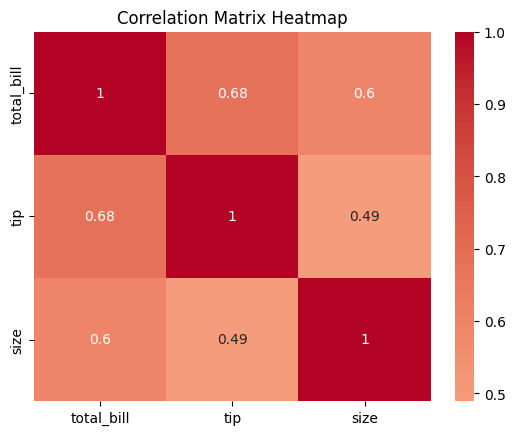

In [35]:
# Section 7 Python cell

LOG.info("--------- Visualize Correlation Matrix as a Heatmap ---------")

plt.figure()

heatmap: Axes = sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
)

heatmap.set_title("Correlation Matrix Heatmap")

plt.show()

Interpretation:

 - Values close to 1 (dark red) = strong positive correlation (both increase together)
 - Values close to -1 (dark blue) = strong negative correlation (one increases, other decreases)
 - Values close to 0 (white) = little or no linear relationship
 - The diagonal is always 1 (each variable correlates perfectly with itself)

From this heatmap, we can see that size and total_bill show a strong positive correlation.

This is a Markdown cell.

## Section 8. Make Plots

Create simple, notebook-friendly plots.

Common charts include:
1. A scatter plot to see relationships between two variables
2. A box plot to compare distributions across groups

A scatter plot shows the relationship between two numeric variables.
In this example:
- Each dot is one data record shown as x vs y.
- Color (hue) provides a third dimension.

A box plot shows the distribution of one numeric variable across groups.
- The box shows the middle 50% of values.
- The line inside the box is the median.
- The whiskers show the range. Dots beyond the whiskers are outliers.


This is a Markdown cell.

2026-06-05 09:54:36 | INFO | EDA-NB | ---- Creating Scatter Plot to see Relationships ------
2026-06-05 09:54:36 | INFO | EDA-NB | ----   Use clean dataframe ---------------------------
2026-06-05 09:54:36 | INFO | EDA-NB | ----   Set x to total bill ---------------------------
2026-06-05 09:54:36 | INFO | EDA-NB | ----   Set y to tip ----------------------------------
2026-06-05 09:54:36 | INFO | EDA-NB | ----   Set the hue (color mapping) to day ------------


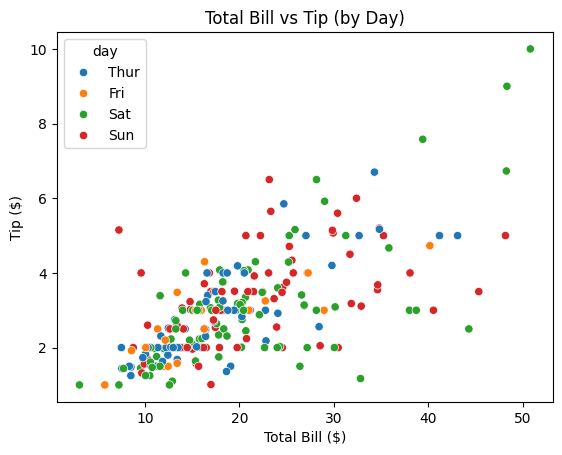

In [36]:
# Section 8 Python cell - use "Run All" so prior cells are executed first.

LOG.info("---- Creating Scatter Plot to see Relationships ------")
LOG.info("----   Use clean dataframe ---------------------------")
LOG.info("----   Set x to total bill ---------------------------")
LOG.info("----   Set y to tip ----------------------------------")
LOG.info("----   Set the hue (color mapping) to day ------------")

plt.figure()

scatter_plt: Axes = sns.scatterplot(
    data=df_clean,
    x="total_bill",
    y="tip",
    hue="day",
)

scatter_plt.set_xlabel("Total Bill ($)")
scatter_plt.set_ylabel("Tip ($)")
scatter_plt.set_title("Total Bill vs Tip (by Day)")

plt.show()

2026-06-05 09:54:37 | INFO | EDA-NB | ------- Creating another chart -------
2026-06-05 09:54:37 | INFO | EDA-NB | ------ Creating Box Plot to see Distribution: ---------
2026-06-05 09:54:37 | INFO | EDA-NB | ------   Use clean dataframe --------------------------
2026-06-05 09:54:37 | INFO | EDA-NB | ------   Set x to day ---------------------------------
2026-06-05 09:54:37 | INFO | EDA-NB | ------   Set y to total bill --------------------------


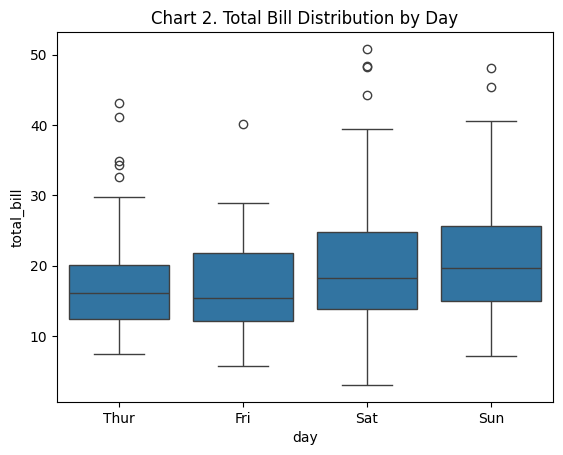

In [37]:
LOG.info("------- Creating another chart -------")

plt.figure()

LOG.info("------ Creating Box Plot to see Distribution: ---------")
LOG.info("------   Use clean dataframe --------------------------")
LOG.info("------   Set x to day ---------------------------------")
LOG.info("------   Set y to total bill --------------------------")

# Box plot to compare distribution across days
box_plt: Axes = sns.boxplot(
    data=df_clean,
    x="day",
    y="total_bill",
)

box_plt.set_title("Chart 2. Total Bill Distribution by Day")

plt.show()

## Section 9. Summary and Next Steps

 The analysis showed that tipping behavior varies across days of the week, with Saturday producing a higher average tip than others. Additionally, differences were observed between smoker and non-smoker groups, with the average tip of a smoker being slightly higher than the average tip of a non-smoker (smoker: 3, non-smoker: 2.99).

The results suggest that tipping behavior is influenced by contextual and demographic factors such as day of the week and smoking status. This implies that customer behavior is not uniform and may be shaped by social setting, group composition, or dining patterns. From a business intelligence perspective, these insights could help restaurant management identify peak tipping periods and better understand customer segments that contribute more to revenue through gratuities. This information could be used to optimize staffing, promotions, or service strategies to increase revenue.


This is a Markdown cell.


In [38]:
LOG.info("========================")
LOG.info("SUMMARY")
LOG.info("========================")
LOG.info(f"Dataset: {DATASET_NAME}")

LOG.info(f"Original rows: {df.shape[0]}")
LOG.info(f"Clean rows:    {df_clean.shape[0]}")

# Unique values (use a real categorical column in tips)
unique_days: np.ndarray = df_clean["day"].unique()
sorted_days: list[str] = sorted(unique_days)

LOG.info(f"Days found in dataset: {sorted_days}")

# Strongest relationship (based on typical tips dataset analysis)
LOG.info("Strongest relationship (typical observation):")
LOG.info("  total_bill and tip (positive correlation)")

LOG.info("Suggested next step:")
LOG.info("  Model tip ~ total_bill using linear regression")

LOG.info("EDA workflow complete")
LOG.info("IMPORTANT: This script creates chart windows.")
LOG.info("Close any chart windows and terminate this process with CTRL+c as needed.")
LOG.info("========================")
LOG.info("Executed successfully!")
LOG.info("========================")

2026-06-05 09:54:37 | INFO | EDA-NB | ========================
2026-06-05 09:54:37 | INFO | EDA-NB | SUMMARY
2026-06-05 09:54:37 | INFO | EDA-NB | ========================
2026-06-05 09:54:37 | INFO | EDA-NB | Dataset: tips
2026-06-05 09:54:37 | INFO | EDA-NB | Original rows: 244
2026-06-05 09:54:37 | INFO | EDA-NB | Clean rows:    244
2026-06-05 09:54:37 | INFO | EDA-NB | Days found in dataset: ['Fri', 'Sat', 'Sun', 'Thur']
2026-06-05 09:54:37 | INFO | EDA-NB | Strongest relationship (typical observation):
2026-06-05 09:54:37 | INFO | EDA-NB |   total_bill and tip (positive correlation)
2026-06-05 09:54:37 | INFO | EDA-NB | Suggested next step:
2026-06-05 09:54:37 | INFO | EDA-NB |   Model tip ~ total_bill using linear regression
2026-06-05 09:54:37 | INFO | EDA-NB | EDA workflow complete
2026-06-05 09:54:37 | INFO | EDA-NB | IMPORTANT: This script creates chart windows.
2026-06-05 09:54:37 | INFO | EDA-NB | Close any chart windows and terminate this process with CTRL+c as needed.
202

## Reminder: Run All before sending to GitHub

Before saving a notebook (and running git add-commit-push), click 'Run All' to generate all outputs and display them in the notebook. 

This is a Markdown cell.
